# Лабораторная №2. Морфология и синтаксис твитов об авиакомпаниях


## 1. Загрузка сохранённых данных и частеречная разметка

Проверяем контрольную сумму и соответствие схемы. `row_id` — исходный индекс CSV, `split` — разбиение первой лабораторной, `tokens_clean` — результат её очистки. Для spaCy декодируем HTML-сущности и выравниваем пробелы; сленг, регистр, отрицания, упоминания и пунктуацию сохраняем. Модель сама токенизирует текст и определяет части речи в контексте.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict, deque
import json
import hashlib
import html
import re
import random
import platform
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from spacy import displacy
from IPython.display import display, Markdown, Image, SVG
try:
    import cairosvg
except (ImportError, OSError):
    cairosvg = None

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "lab1/notebook.ipynb").exists()), None)
DATA_DIR = ROOT / "data/lab1"
if not (DATA_DIR / "documents.jsonl").exists():
    raise FileNotFoundError("Сначала выполните lab1/notebook.ipynb до ячейки сохранения данных.")
manifest = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
assert manifest["schema_version"] == 1
assert hashlib.sha256((DATA_DIR / "documents.jsonl").read_bytes()).hexdigest() == manifest["documents_sha256"]
frame = pd.read_json(DATA_DIR / "documents.jsonl", lines=True).sort_values("row_id").reset_index(drop=True)
assert len(frame) == manifest["rows"] and frame.row_id.is_unique
assert set(frame.label) == {"negative", "neutral", "positive"}
assert frame.split.value_counts().to_dict() == {"train": manifest["train_rows"], "test": manifest["test_rows"]}
assert frame.tokens_clean.map(lambda x: x[0] == "<s>" and x[-1] == "</s>").all()
frame["text_nlp"] = frame.text.map(lambda x: re.sub(r"\s+", " ", html.unescape(x)).strip())
OUT = ROOT / "data/lab2"
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 40)
print(f"Загружено {len(frame)} документов. SHA-256 проверен.")
display(pd.crosstab(frame.label, frame.split))

nlp = spacy.load("en_core_web_sm")
print("spaCy:", spacy.__version__, "| модель:", nlp.meta["version"])
docs = list(nlp.pipe(frame.text_nlp, batch_size=128))
by_id = dict(zip(frame.row_id, docs))
print("Разобрано твитов:", len(docs))
display(pd.DataFrame([{"Токен": t.text, "Лемма": t.lemma_, "POS": t.pos_,
                       "Морфология": str(t.morph), "Связь": t.dep_, "Главное слово": t.head.text}
                      for t in docs[0]]))

Загружено 14640 документов. SHA-256 проверен.


split,test,train
label,,
negative,1835,7343
neutral,620,2479
positive,473,1890


spaCy: 3.8.16 | модель: 3.8.0
Разобрано твитов: 14640


,Токен,Лемма,POS,Морфология,Связь,Главное слово
0,@VirginAmerica,@VirginAmerica,PROPN,Number=Sing,npadvmod,said
1,What,what,PRON,,det,@dhepburn
2,@dhepburn,@dhepburn,PROPN,Number=Sing,nsubj,said
3,said,say,VERB,Tense=Past|VerbForm=Fin,ROOT,said
4,.,.,PUNCT,PunctType=Peri,punct,said


## 2. Частоты частей речи и сравнение классов

Считаем токены, исключая пробелы, пунктуацию, символы, URL, email и `@упоминания`. Учитываем все вхождения, а не только уникальные слова. Для сравнения классов знаменатель — число учитываемых токенов **внутри каждого класса**. Иначе преобладание негативных отзывов в датасете исказило бы результат.

Основные метки: NOUN — существительное, PROPN — имя собственное, VERB — глагол, AUX — вспомогательный глагол, ADJ — прилагательное, ADV — наречие, PRON — местоимение, INTJ — междометие, ADP — предлог, DET — определитель.

,POS,Токенов,"Доля, %"
0,NOUN,49869,20.19
1,VERB,35849,14.51
2,PRON,30345,12.28
3,ADP,25719,10.41
4,AUX,18921,7.66
5,PROPN,16315,6.60
6,DET,15065,6.10
7,ADJ,13482,5.46
8,ADV,12957,5.24
9,PART,9123,3.69


,negative,neutral,positive
PRON,12.13,12.62,12.70
VERB,14.83,14.14,13.18
PART,4.07,3.21,2.21
NOUN,20.27,19.23,20.97
AUX,7.90,7.97,5.89
DET,6.14,5.82,6.24
ADV,5.35,4.10,6.21
ADJ,5.37,4.31,7.47
ADP,10.34,10.78,10.28
PROPN,5.29,10.27,9.09


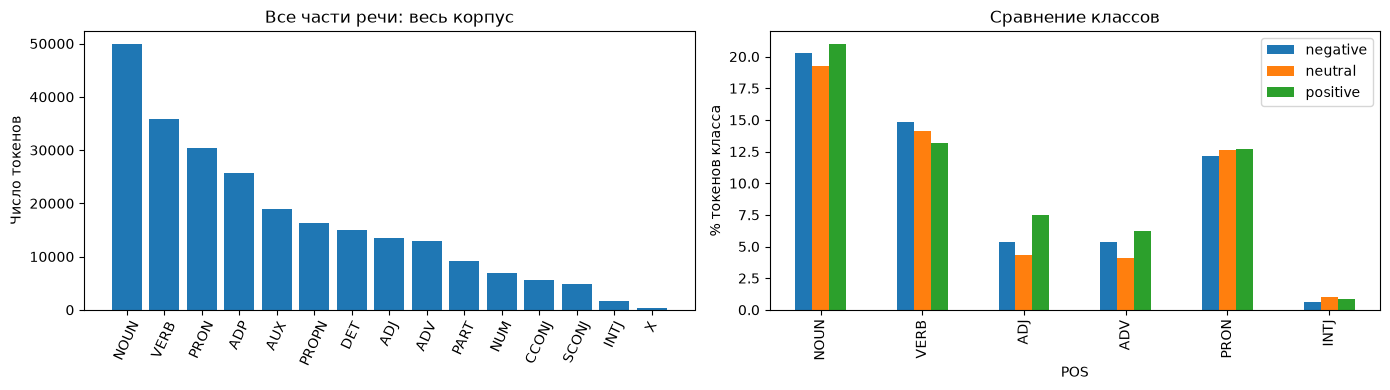

ADJ: максимум — positive (7.47%), минимум — neutral (4.31%), разница 3.16 п.п.
VERB: максимум — negative (14.83%), минимум — positive (13.18%), разница 1.65 п.п.
INTJ: максимум — neutral (1.00%), минимум — negative (0.59%), разница 0.41 п.п.


In [2]:
def include_token(t):
    return not (t.is_space or t.is_punct or t.like_url or t.like_email
                or t.text.startswith("@") or t.pos_ in {"SYM", "PUNCT", "SPACE"})

pos_counts = Counter()
class_counts = defaultdict(Counter)
for row, doc in zip(frame.itertuples(), docs):
    counts = Counter(t.pos_ for t in doc if include_token(t))
    pos_counts.update(counts)
    class_counts[row.label].update(counts)

pos_table = pd.DataFrame(pos_counts.most_common(), columns=["POS", "Токенов"])
pos_table["Доля, %"] = 100 * pos_table["Токенов"] / pos_table["Токенов"].sum()
class_absolute = pd.DataFrame(class_counts).fillna(0).astype(int)
class_share = class_absolute.div(class_absolute.sum(axis=0), axis=1) * 100
class_share = class_share[["negative", "neutral", "positive"]]
display(pos_table.round(2))
display(class_share.round(2))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(pos_table.POS, pos_table["Токенов"])
axes[0].tick_params(axis="x", rotation=65)
axes[0].set(title="Все части речи: весь корпус", ylabel="Число токенов")
class_share.loc[["NOUN", "VERB", "ADJ", "ADV", "PRON", "INTJ"]].plot.bar(ax=axes[1])
axes[1].set(title="Сравнение классов", ylabel="% токенов класса", xlabel="POS")
fig.tight_layout()
plt.show()
for pos in ["ADJ", "VERB", "INTJ"]:
    values = class_share.loc[pos]
    print(f"{pos}: максимум — {values.idxmax()} ({values.max():.2f}%), "
          f"минимум — {values.idxmin()} ({values.min():.2f}%), разница {values.max()-values.min():.2f} п.п.")

Это описательные различия, а не доказательство причинной связи или статистической значимости. Части речи показывают стиль сообщения, но не его полярность: например, прилагательные встречаются и в похвале, и в жалобах. Надёжность сравнения ограничена ошибками теггера на коротких разговорных текстах.

### Шесть проверенных ошибок на реальных твитах

Примеры отобраны вручную после просмотра разметки. В таблице сохраняются исходный индекс, токен и ожидаемая метка по смыслу конкретного предложения. Это небольшой разбор ошибок, а не оценка точности на всём корпусе.

In [3]:
audit_spec = [
    (13, 13, "U", "PRON", "Сокращение you: U take all the stress away. Здесь это подлежащее-местоимение, а не существительное."),
    (26, 4, "ur", "PRON", "Сокращение your перед vegan food options: притяжательное местоимение, ошибочно принято за имя собственное."),
    (244, 3, "luv", "VERB", "Разговорное написание love: (I) luv Virgin America. Пропущенное подлежащее и нестандартное написание мешают распознать глагол."),
    (311, 10, "Thx", "INTJ", "Самостоятельное Thx! — формула благодарности, функционирующая как междометие; модель ставит PROPN."),
    (365, 8, "ASAP", "ADV", "ASAP означает as soon as possible и описывает, когда нужен чек. Это обстоятельство времени, а не имя собственное."),
    (391, 1, "omg", "INTJ", "Эмоциональное omg (oh my God) рядом с эмодзи: междометное восклицание, а не имя собственное."),
]
audit_rows = []
for row_id, token_i, spelling, expected, explanation in audit_spec:
    doc = by_id[row_id]
    token = doc[token_i]
    assert token.text == spelling, "Изменилась токенизация: перепроверьте пример вручную."
    audit_rows.append({"row_id": row_id, "Текст": doc.text, "Токен": token.text,
                       "Модель": token.pos_, "Ожидается": expected,
                       "Расхождение": token.pos_ != expected, "Объяснение": explanation})
audit = pd.DataFrame(audit_rows)
display(audit)
assert audit["Расхождение"].sum() >= 5, "Версия модели изменилась — нужно пересмотреть примеры."

,row_id,Текст,Токен,Модель,Ожидается,Расхождение,Объяснение
0,13,@VirginAmerica @virginmedia I'm flying your #fabulous #Seductive skies again! U take all the #stress away from travel http://t.co/ahlXHhKiyn,U,NOUN,PRON,True,"Сокращение you: U take all the stress away. Здесь это подлежащее-местоимение, а не существительное."
1,26,@VirginAmerica What happened 2 ur vegan food options?! At least say on ur site so i know I won't be able 2 eat anything for next 6 hrs #fail,ur,PROPN,PRON,True,"Сокращение your перед vegan food options: притяжательное местоимение, ошибочно принято за имя собственное."
2,244,"@VirginAmerica classiq, luv Virgin America. Greetingz",luv,PROPN,VERB,True,Разговорное написание love: (I) luv Virgin America. Пропущенное подлежащее и нестандартное написание мешают распознать глагол.
3,311,.@VirginAmerica They were very understanding and helped me out. Thx! #Comps,Thx,PROPN,INTJ,True,"Самостоятельное Thx! — формула благодарности, функционирующая как междометие; модель ставит PROPN."
4,365,"@VirginAmerica Done, but I need the receipt ASAP. Could you please help? #150219-000114",ASAP,PROPN,ADV,True,"ASAP означает as soon as possible и описывает, когда нужен чек. Это обстоятельство времени, а не имя собственное."
5,391,@VirginAmerica omg omg😍😍 nonstop Dallas to Austin on virgin✨😱✈️,omg,PROPN,INTJ,True,"Эмоциональное omg (oh my God) рядом с эмодзи: междометное восклицание, а не имя собственное."


## 3. Десять деревьев зависимостей

Для коротких твитов условно считаем средней длиной 10–20 словесных токенов в предложении. Выбираем без повторов 4 предложения из negative и по 3 из neutral/positive с фиксированным seed=42. URL исключаются из этой демонстрационной выборки. Ни текст, ни связи вручную не исправляем: схемы показывают именно разбор модели.

Стрелка идёт от главного слова к зависимому; над ней написан тип связи (`nsubj` — подлежащее, `dobj` — прямое дополнение, `amod` — определение, `acomp` — предикативное прилагательное). Под токенами указаны части речи.

,row_id,Класс,Слов,Предложение
0,13477,negative,10,@AmericanAir I would purchase it if I was there by choice
1,2144,negative,19,@united I'm rebooked on a flight tomorrow even though I had 1st class seat orig I have a lousy coach seat
2,665,negative,10,keep your paper work ready and don't delay our flights(#1585)and meetings @ChooseChicago
3,5593,negative,15,well I HAD a car & free place 2 stay had I known Unacceptable treatment from Spvsr.
4,5250,neutral,12,@SouthwestAir and @USAirways have Cancelled Flightled flights after 525 pm today due to winter storm.
5,4778,neutral,11,@SouthwestAir got an email confirmation of wifi purchase on a recent flight.
6,3387,neutral,15,@united @estellevw does she need to complain on Twitter for the refund or is it auto-applied?
7,12003,positive,10,It's going to take an hour to type it out
8,1672,positive,14,@united Thank y'all for being an amazing airline who knows how to treat their customers.
9,10700,positive,15,@USAirways you can thank supervisor Jeanine and her coworkers for the excellent customer service they provided


**1. row_id=13477, negative, 10 слов**

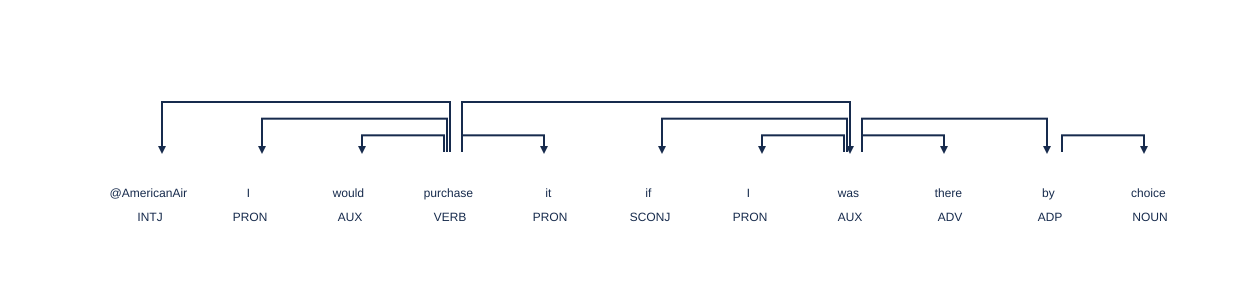

**2. row_id=2144, negative, 19 слов**

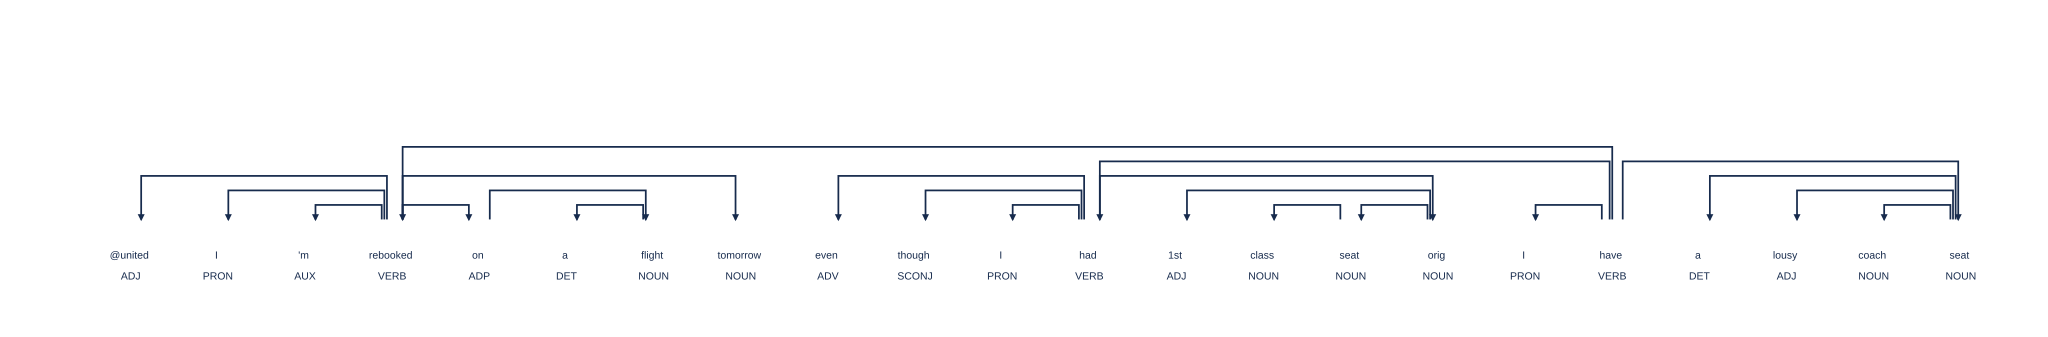

**3. row_id=665, negative, 10 слов**

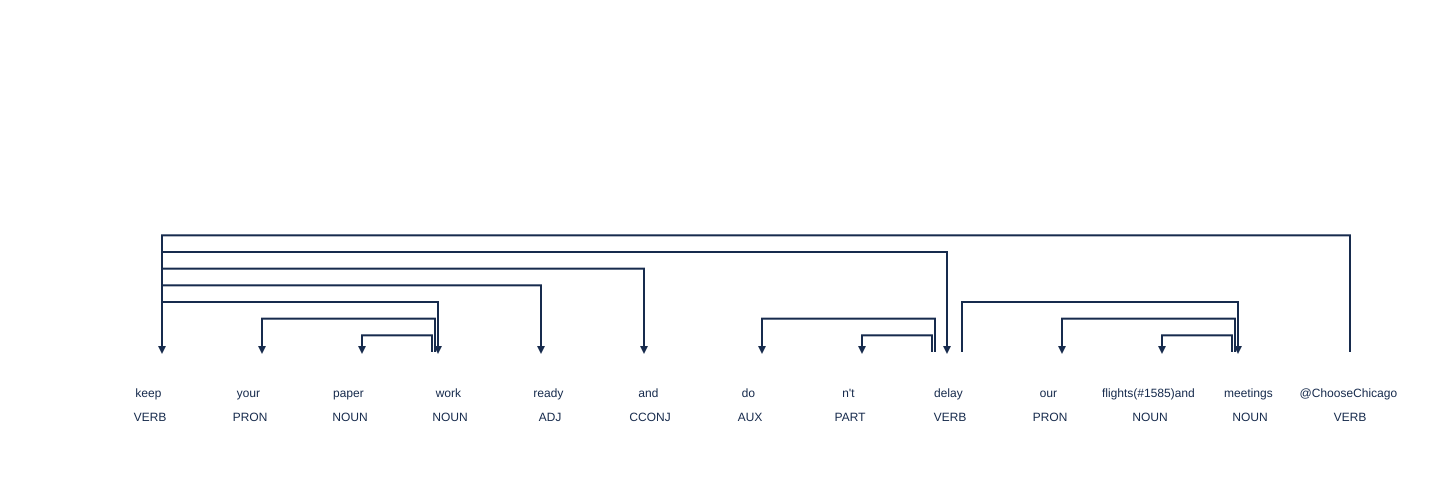

**4. row_id=5593, negative, 15 слов**

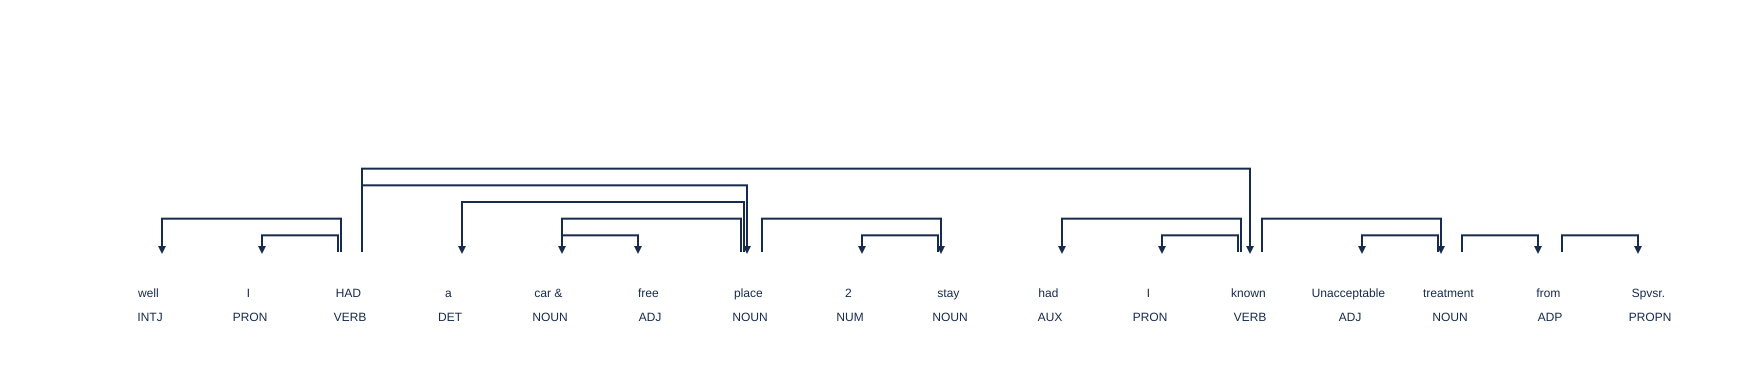

**5. row_id=5250, neutral, 12 слов**

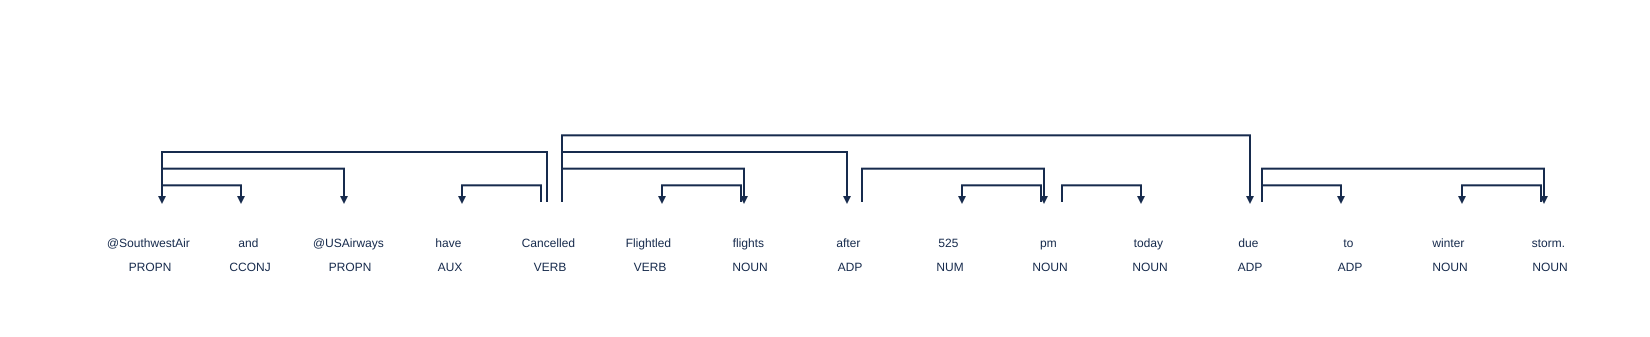

**6. row_id=4778, neutral, 11 слов**

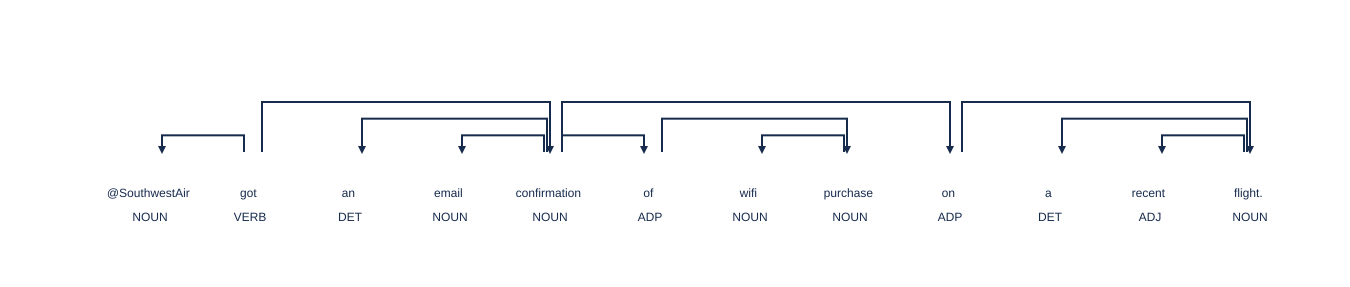

**7. row_id=3387, neutral, 15 слов**

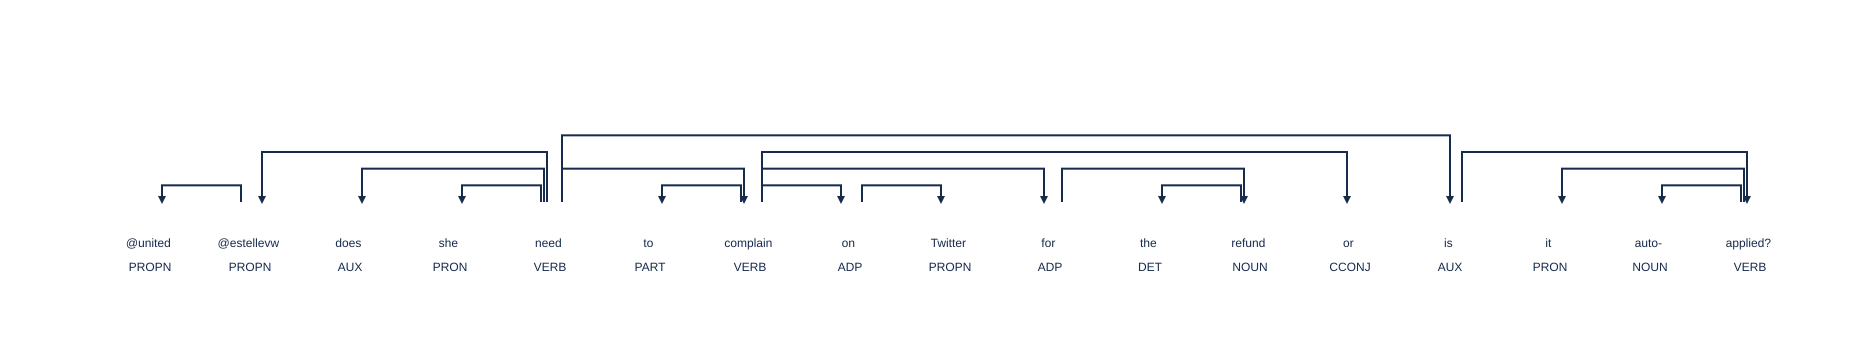

**8. row_id=12003, positive, 10 слов**

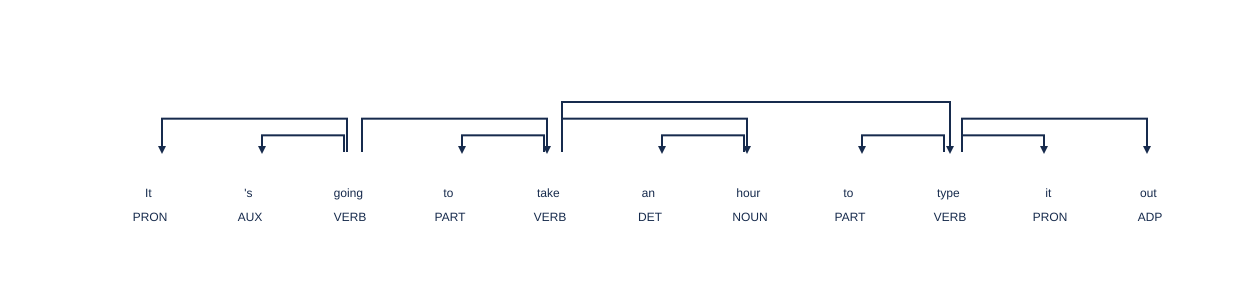

**9. row_id=1672, positive, 14 слов**

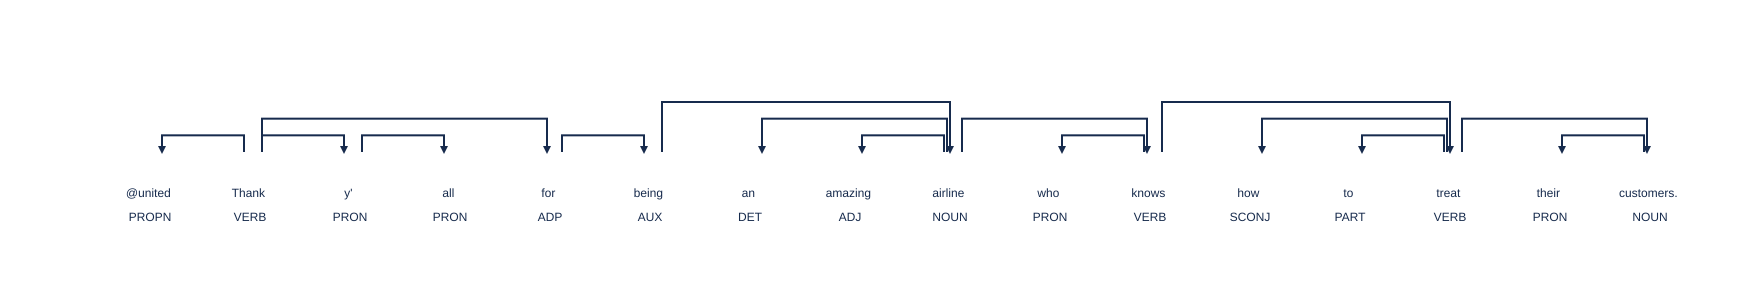

**10. row_id=10700, positive, 15 слов**

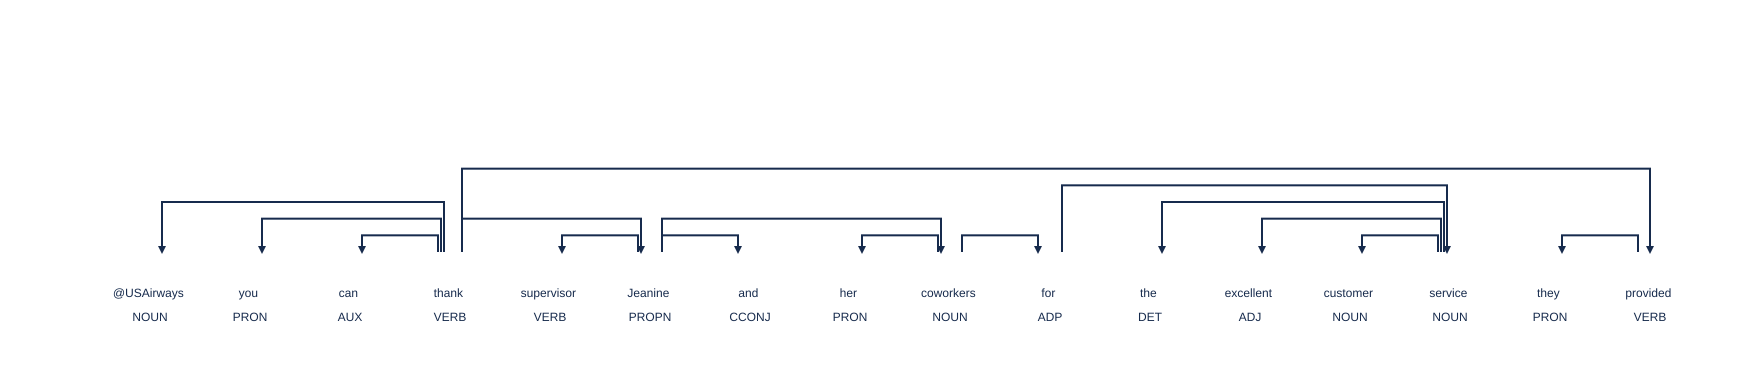

In [4]:
pools = defaultdict(list)
seen_sentences = set()
for row, doc in zip(frame.itertuples(), docs):
    for sent in doc.sents:
        length = sum(t.is_alpha for t in sent)
        if (10 <= length <= 20 and any(t.pos_ in {"VERB", "AUX"} for t in sent)
                and not any(t.like_url for t in sent) and sent.text not in seen_sentences):
            pools[row.label].append((row.row_id, row.label, sent, length))
            seen_sentences.add(sent.text)
rng = random.Random(42)
selected = []
for label, count in [("negative", 4), ("neutral", 3), ("positive", 3)]:
    selected.extend(rng.sample(pools[label], count))
assert len(selected) == 10
display(pd.DataFrame([{"row_id": r, "Класс": c, "Слов": length, "Предложение": s.text}
                      for r, c, s, length in selected]))
for i, (row_id, label, sent, length) in enumerate(selected, 1):
    display(Markdown(f"**{i}. row_id={row_id}, {label}, {length} слов**"))
    svg = displacy.render(sent, style="dep", jupyter=False,
                         options={"compact": True, "distance": 100, "font_size": "14px",
                                  "bg": "#ffffff", "color": "#172b4d", "offset_x": 150})
    (OUT / f"dependency_{i:02d}.svg").write_text(svg, encoding="utf-8")
    if cairosvg is None:
        display(SVG(svg))
    else:
        png = cairosvg.svg2png(bytestring=svg.encode("utf-8"), background_color="white")
        (OUT / f"dependency_{i:02d}.png").write_bytes(png)
        display(Image(data=png))

## 4. Извлечение пар «аспект — прилагательное» по дереву

Используем два типа связей: `amod` (great service → service/great) и предикативное прилагательное (`service is good` → service/good). Обрабатываем однородные прилагательные и подлежащие, а также отрицания `not`, `never`, `no` в непосредственно связанной конструкции. Составной аспект собирается из `compound` (customer service).

Обход идёт по дочерним узлам дерева. Извлечение не использует расстояние между словами в строке или список положительных/отрицательных слов. Отрицание, сарказм, косвенная оценка и ошибки дерева всё равно могут приводить к ошибкам.

URL и @упоминания исключаем из обеих частей пары, даже если теггер ошибочно назвал их прилагательными.

In [5]:
def walk_tree(root):
    yield root
    for child in root.children:
        yield from walk_tree(child)


def noun_group(noun):
    return [noun, *[t for t in noun.conjuncts if t.pos_ in {"NOUN", "PROPN"}]]


def adjective_group(adjective):
    return [adjective, *[t for t in adjective.conjuncts if t.pos_ == "ADJ"]]


def aspect_name(noun):
    parts = sorted([noun, *[t for t in noun.children if t.dep_ == "compound" and include_token(t)]], key=lambda t: t.i)
    return " ".join(t.lemma_.lower() for t in parts)


def has_negation(node):
    return any(t.dep_ == "neg" or (t.dep_ == "det" and t.lower_ == "no") for t in node.children)


def extract_pairs(doc):
    found = {}
    def add(noun, adjective, predicate=None):
        for n in noun_group(noun):
            for a in adjective_group(adjective):
                if not include_token(n) or not include_token(a):
                    continue
                negated = (has_negation(a) or has_negation(n)
                           or (predicate is not None and has_negation(predicate)))
                value = ("not " if negated else "") + a.lemma_.lower()
                found[(n.i, a.i)] = {"aspect": aspect_name(n), "opinion": value,
                                      "negated": negated, "sentence": n.sent.text}
    for sent in doc.sents:
        for token in walk_tree(sent.root):
            if token.dep_ == "amod" and token.pos_ == "ADJ" and token.head.pos_ in {"NOUN", "PROPN"}:
                add(token.head, token)
            if token.pos_ in {"VERB", "AUX"}:
                subjects = [t for t in token.children if t.dep_ in {"nsubj", "nsubjpass"} and t.pos_ in {"NOUN", "PROPN"}]
                adjectives = [t for t in token.children if t.dep_ in {"acomp", "attr"} and t.pos_ == "ADJ"]
                for subject in subjects:
                    for adjective in adjectives:
                        add(subject, adjective, token)
            if token.pos_ == "ADJ":
                for subject in token.children:
                    if subject.dep_ == "nsubj" and subject.pos_ in {"NOUN", "PROPN"}:
                        add(subject, token, token)
    return list(found.values())

pair_rows = []
for row, doc in zip(frame.itertuples(), docs):
    pair_rows.extend({"row_id": row.row_id, "label": row.label, **pair} for pair in extract_pairs(doc))
pairs = pd.DataFrame(pair_rows)
print("Извлечено вхождений пар:", len(pairs), "| Твитов с парами:", pairs.row_id.nunique())
display(pairs.head(10))

Извлечено вхождений пар: 9372 | Твитов с парами: 6363


,row_id,label,aspect,opinion,negated,sentence
0,3,negative,entertainment,obnoxious,False,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces & they have little recourse"
1,3,negative,recourse,little,False,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces & they have little recourse"
2,4,negative,thing,big,False,@VirginAmerica and it's a really big bad thing about it
3,4,negative,thing,bad,False,@VirginAmerica and it's a really big bad thing about it
4,5,negative,thing,only,False,it's really the only bad thing about flying VA
5,5,negative,thing,bad,False,it's really the only bad thing about flying VA
6,7,neutral,opportunity,prime,False,"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there."
7,10,neutral,cause,second,False,@VirginAmerica did you know that suicide is the second leading cause of death among teens 10-24
8,11,positive,graphic,pretty,False,@VirginAmerica I <3 pretty graphics.
9,11,positive,iconography,minimal,False,so much better than minimal iconography.


## 5. Топ-20 пар и анализ смысла

Считаем вхождения пар, а не количество документов: в одном твите может быть несколько пар. Пары нормализованы леммами. Класс в таблице относится ко всему твиту и не обязательно совпадает с оценкой отдельного аспекта.

,aspect,opinion,count,negative,neutral,positive
0,flight,late,92,81,6,5
1,night,last,58,46,8,4
2,airline,bad,51,51,0,0
3,flight,next,49,32,10,7
4,time,first,41,25,6,10
5,customer service,bad,40,40,0,0
6,class,first,39,23,9,7
7,flight,flightled,38,35,1,2
8,weather,bad,38,28,5,5
9,airline,other,37,28,3,6


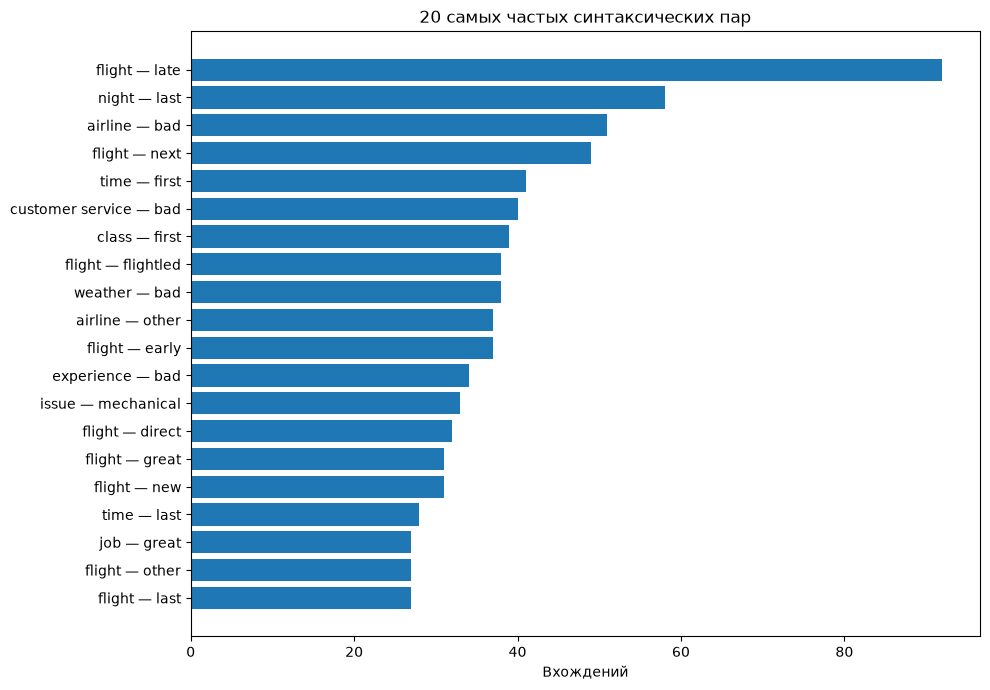

,aspect,opinion,row_id,label,sentence
0,flight,late,82,negative,Whenever I (begrudgingly) use any other airline I'm delayed and Late Flight :(
92,night,last,48,neutral,@VirginAmerica @ladygaga @carrieunderwood After last night #tribute #SoundOfMusic #Oscars2015 @ladygaga!
150,airline,bad,177,negative,You r the worse airlines!
201,flight,next,83,negative,I will Cancelled Flight my next four flights I planned.#neverflyvirginforbusiness
250,time,first,41,negative,"@VirginAmerica Hey, first time flyer next week - excited!"


In [6]:
pair_counts = pairs.groupby(["aspect", "opinion"]).size().sort_values(ascending=False)
top20 = pair_counts.head(20).rename("count").reset_index()
class_pairs = pd.crosstab([pairs.aspect, pairs.opinion], pairs.label)
top20 = top20.merge(class_pairs, left_on=["aspect", "opinion"], right_index=True, how="left")
for label in ["negative", "neutral", "positive"]:
    if label not in top20:
        top20[label] = 0
assert len(top20) == 20
display(top20)
fig, ax = plt.subplots(figsize=(10, 7))
labels = top20.aspect + " — " + top20.opinion
ax.barh(labels[::-1], top20["count"][::-1])
ax.set(xlabel="Вхождений", title="20 самых частых синтаксических пар")
fig.tight_layout()
plt.show()
# Реальные контексты пяти наиболее частых пар.
contexts = top20.head(5).merge(pairs, on=["aspect", "opinion"]).drop_duplicates(["aspect", "opinion"])
display(contexts[["aspect", "opinion", "row_id", "label", "sentence"]])

По рассчитанному топу: `flight — late` встречается 92 раза, из них 81 раз в negative; `airline — bad` — 51 раз, все в negative; `customer service — bad` — 40 раз, все в negative. `flight — great` встречается 31 раз, из них 30 в positive. Эти пары содержательно отражают задержки, качество сервиса и положительный опыт.

Однако `night — last` и `flight — next` описывают время, а не оценку. Пара `flight — flightled` (38 вхождений) — ошибка интерпретации шумного исходного текста: в CSV встречается фрагмент `Cancelled Flightled`. Модель принимает `Flightled` за прилагательное. Это не корректная оценка рейса.

Класс документа не задаёт автоматически полярность каждой пары: в негативном отзыве возможны похвала отдельной детали, противопоставление или сарказм. Алгоритм видит только выбранные синтаксические конструкции; жалоба «they lost my bag» не содержит прилагательного и сюда не попадёт. Без размеченных аспектов нельзя заявлять точность на всём корпусе. Метод не является классификатором токсичности или иронии.

## 6. Разрешение анафоры по правилам

Ищем английские местоимения третьего лица `he/him/his`, `she/her/hers`, `it/its`, `they/them/their/theirs`, а также самостоятельные указательные `this/that` (PronType=Dem, исключая относительное that). Кандидаты — существительные и имена **слева** в том же твите, в текущем или предыдущем предложении. Между разными твитами связь не ищется.

Фильтруем несовпадающее число и известный род. В английском у большинства существительных spaCy не выдаёт род: неизвестный род не объявляется совпадением. Для he/she дополнительно ограничиваем кандидатов людьми (NER PERSON или небольшой явный список обозначений людей); для it исключаем людей. При равных условиях используем синтаксическое расстояние — число рёбер между токенами. Для разных предложений соединяем их корни через виртуальный общий узел.

Приоритет: ближайшее предложение, известное согласование рода, минимальное расстояние по дереву, ближайшее слово слева. При отсутствии кандидата оставляем местоимение. Личное they с единственным числом, ссылка на целую ситуацию, неоднозначность и безличное it — ограничения этого учебного алгоритма.

In [7]:
THIRD_PERSON = {"he", "him", "his", "she", "her", "hers", "it", "its", "they", "them", "their", "theirs", "this", "that"}
PEOPLE = {"man", "woman", "boy", "girl", "father", "mother", "pilot", "agent", "attendant", "employee",
          "representative", "manager", "person", "passenger", "customer", "staff", "crew", "husband", "wife"}
GENDER_HINT = {"man": "Masc", "boy": "Masc", "father": "Masc", "husband": "Masc",
               "woman": "Fem", "girl": "Fem", "mother": "Fem", "wife": "Fem"}


def syntax_distance(a, b):
    chain_a = [a, *a.ancestors]
    chain_b = [b, *b.ancestors]
    positions = {t.i: i for i, t in enumerate(chain_a)}
    for j, token in enumerate(chain_b):
        if token.i in positions:
            return positions[token.i] + j
    return (len(chain_a) - 1) + (len(chain_b) - 1) + 2


def human(noun):
    return noun.ent_type_ == "PERSON" or noun.lemma_.lower() in PEOPLE


def noun_gender(noun):
    values = noun.morph.get("Gender")
    return values[0] if values else GENDER_HINT.get(noun.lemma_.lower())


def antecedent(pronoun, doc, sentence_ids):
    if pronoun.dep_ == "expl":
        return None
    number = pronoun.morph.get("Number")
    gender = pronoun.morph.get("Gender")
    candidates = []
    for noun in doc[:pronoun.i]:
        gap = sentence_ids[pronoun.i] - sentence_ids[noun.i]
        if gap > 1 or noun.pos_ not in {"NOUN", "PROPN"} or not include_token(noun):
            continue
        candidate_number = noun.morph.get("Number")
        if number and candidate_number and not set(number).intersection(candidate_number):
            continue
        g = noun_gender(noun)
        if gender and g and g not in gender:
            continue
        if pronoun.lower_ in {"he", "him", "his", "she", "her", "hers"} and not human(noun):
            continue
        if pronoun.lower_ in {"it", "its"} and human(noun):
            continue
        missing_gender = int(bool(gender) and g is None)
        distance = syntax_distance(pronoun, noun)
        candidates.append(((gap, missing_gender, distance, pronoun.i - noun.i), noun, distance))
    if not candidates:
        return None
    _, noun, distance = min(candidates, key=lambda item: item[0])
    return noun, distance


def resolve_anaphora(doc):
    sentence_ids = {t.i: i for i, sent in enumerate(doc.sents) for t in sent}
    edits, resolutions = [], []
    for pronoun in doc:
        if pronoun.lower_ not in THIRD_PERSON or pronoun.pos_ not in {"PRON", "DET"}:
            continue
        if pronoun.lower_ in {"this", "that"} and (pronoun.pos_ != "PRON" or "Dem" not in pronoun.morph.get("PronType")):
            continue
        match = antecedent(pronoun, doc, sentence_ids)
        if match is None:
            resolutions.append({"pronoun": pronoun.text, "antecedent": None, "distance": None,
                                "pronoun_morph": str(pronoun.morph), "noun_morph": None})
            continue
        noun, distance = match
        compound = sorted([noun, *[c for c in noun.children if c.dep_ == "compound" and c.i < pronoun.i and include_token(c)]], key=lambda t: t.i)
        replacement = " ".join(t.text for t in compound)
        possessive = "Yes" in pronoun.morph.get("Poss") or pronoun.tag_ == "PRP$"
        if possessive:
            replacement += "'" if replacement.lower().endswith("s") else "'s"
        if pronoun.is_sent_start:
            replacement = replacement[0].upper() + replacement[1:]
        edits.append((pronoun.idx, pronoun.idx + len(pronoun.text), replacement))
        resolutions.append({"pronoun": pronoun.text, "antecedent": noun.text, "distance": distance,
                            "pronoun_morph": str(pronoun.morph), "noun_morph": str(noun.morph)})
    modified = doc.text
    for start, end, replacement in reversed(edits):
        modified = modified[:start] + replacement + modified[end:]
    return modified, resolutions

anaphora_rows = []
anaphora_texts = []
for row, doc in zip(frame.itertuples(), docs):
    modified, resolutions = resolve_anaphora(doc)
    if resolutions:
        anaphora_texts.append({"row_id": row.row_id, "Исходный": doc.text, "После правил": modified})
        anaphora_rows.extend({"row_id": row.row_id, **r} for r in resolutions)
anaphora = pd.DataFrame(anaphora_rows)
anaphora_examples = pd.DataFrame(anaphora_texts)
resolved = anaphora.antecedent.notna()
print(f"Найдено местоимений: {len(anaphora)}; найден кандидат: {resolved.sum()} ({resolved.mean():.1%}).")
print("Это покрытие правила, не точность: правильность кандидатов здесь не известна.")
review_notes = {
    43: "Удачно: it expires относится к ticket, несмотря на более близкое city.",
    57: "Удачно: She относится к Lady Gaga; сохраняется составное имя.",
    89: "Удачно: it be back up относится к site из предыдущего предложения.",
    3: "Ошибка: they относится к guests, но правило выбирает faces; число совпадает у обоих кандидатов.",
    61: "Ошибка: they относится к flights, а правило выбирает weeks. Одной близости и согласования числа мало.",
    106: "Ошибка: This отсылает ко всей ситуации с прерванным звонком; замена на service line теряет смысл и сарказм.",
}
anaphora_review = anaphora_examples[anaphora_examples.row_id.isin(review_notes)].copy()
anaphora_review["Ручной разбор"] = anaphora_review.row_id.map(review_notes)
display(anaphora_review)
display(anaphora[anaphora.row_id.isin(review_notes)])

Найдено местоимений: 5804; найден кандидат: 2984 (51.4%).
Это покрытие правила, не точность: правильность кандидатов здесь не известна.


,row_id,Исходный,После правил,Ручной разбор
0,3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces & they have little recourse","@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces & faces have little recourse","Ошибка: they относится к guests, но правило выбирает faces; число совпадает у обоих кандидатов."
7,43,@VirginAmerica I have an unused ticket but moved to a new city where you don't fly. How can I fly with you before it expires? #travelhelp,@VirginAmerica I have an unused ticket but moved to a new city where you don't fly. How can I fly with you before ticket expires? #travelhelp,"Удачно: it expires относится к ticket, несмотря на более близкое city."
11,57,@VirginAmerica @ladygaga @carrieunderwood I'm Lady Gaga!!! She is amazing! 😊,@VirginAmerica @ladygaga @carrieunderwood I'm Lady Gaga!!! Lady Gaga is amazing! 😊,Удачно: She относится к Lady Gaga; сохраняется составное имя.
12,61,@VirginAmerica I called a 3-4 weeks ago about adding 3 flights from 2014 to my Elevate...they still haven't shown up...help!,@VirginAmerica I called a 3-4 weeks ago about adding 3 flights from 2014 to my Elevate...weeks still haven't shown up...help!,"Ошибка: they относится к flights, а правило выбирает weeks. Одной близости и согласования числа мало."
19,89,@VirginAmerica Why is the site down? When will it be back up?,@VirginAmerica Why is the site down? When will site be back up?,Удачно: it be back up относится к site из предыдущего предложения.
23,106,@VirginAmerica called your service line and was hung up on. This is awesome. #sarcasm,@VirginAmerica called your service line and was hung up on. Service line is awesome. #sarcasm,Ошибка: This отсылает ко всей ситуации с прерванным звонком; замена на service line теряет смысл и сарказм.


,row_id,pronoun,antecedent,distance,pronoun_morph,noun_morph
0,3,it,NaN,NaN,Case=Nom|Gender=Neut|Number=Sing|Person=3|PronType=Prs,NaN
1,3,they,faces,6.0,Case=Nom|Number=Plur|Person=3|PronType=Prs,Number=Plur
9,43,it,ticket,5.0,Case=Nom|Gender=Neut|Number=Sing|Person=3|PronType=Prs,Number=Sing
14,57,She,Gaga,4.0,Case=Nom|Gender=Fem|Number=Sing|Person=3|PronType=Prs,Number=Sing
15,61,they,weeks,4.0,Case=Nom|Number=Plur|Person=3|PronType=Prs,Number=Plur
23,89,it,site,4.0,Case=Nom|Gender=Neut|Number=Sing|Person=3|PronType=Prs,Number=Sing
27,106,This,line,4.0,Number=Sing|PronType=Dem,Number=Sing


Правило не понимает сюжет твита и выбирает ближайшего совместимого кандидата по формальным признакам. Оно способно ошибочно связать it с местом вместо рейса или they с ближайшим множественным существительным вместо сотрудников. Безличное it не всегда получает метку `expl`; такие ошибки также остаются. Повтор существительного делает текст менее естественным, а замена не восстанавливает пропущенный контекст переписки. Поэтому результат используется как демонстрация эвристики, не как надёжное исправление текстов.

## Сохранение результатов и воспроизводимость

Сохраняем таблицы и схемы в `data/lab2` (локальные производные данные, не исходный датасет в Git). Документация: [лингвистические признаки spaCy](https://spacy.io/usage/linguistic-features), [визуализатор displaCy](https://spacy.io/usage/visualizers), [английская модель](https://spacy.io/models/en#en_core_web_sm).

In [8]:
pos_table.to_csv(OUT / "pos_counts.csv", index=False)
class_share.to_csv(OUT / "pos_by_class_percent.csv")
audit.to_json(OUT / "pos_errors.json", orient="records", force_ascii=False, indent=2)
pairs.to_json(OUT / "aspect_pairs.jsonl", orient="records", lines=True, force_ascii=False)
top20.to_csv(OUT / "top20_pairs.csv", index=False)
anaphora_review.to_json(OUT / "anaphora_review.json", orient="records", force_ascii=False, indent=2)
anaphora.to_json(OUT / "anaphora_links.jsonl", orient="records", lines=True, force_ascii=False)
anaphora_examples.to_json(OUT / "anaphora_texts.jsonl", orient="records", lines=True, force_ascii=False)
versions = {"python": platform.python_version(), "spacy": spacy.__version__, "model": nlp.meta["version"],
            "input_sha256": manifest["documents_sha256"], "documents": len(frame),
            "dependency_trees": len(selected), "pos_error_examples": int(audit["Расхождение"].sum()),
            "pair_occurrences": len(pairs), "pronouns": len(anaphora), "pronouns_with_candidate": int(resolved.sum())}
(OUT / "run_manifest.json").write_text(json.dumps(versions, indent=2), encoding="utf-8")
print("Результаты сохранены в data/lab2. Таблица топ-20:", len(top20), "строк; схем:", len(selected))

Результаты сохранены в data/lab2. Таблица топ-20: 20 строк; схем: 10
